# Using BRICS and ChEMBL Fragment Libraries

> ### In this tutorial we will cover:
> - how we can convert a list of molecules to BRICS fragments
> - how we can query the ChEMBL database to obtain a fragment library

In other tutorials we illustrate how to make simple fragment libraries from scratch, and we showcase how to use fragment libraries in generative pipelines. 

Of course, we don't need to re-invent the wheel with molecular fragments because good fragment libraries already exist out there, and we can use them directly within BuildAMol! 

So in this tutorial, we start by using the BRICS fragmentation algorithm by [Degen et al.](https://chemistry-europe.onlinelibrary.wiley.com/doi/10.1002/cmdc.200800178) to create our own fragment library for Oxazolidinone antibiotics.

## Using BRICS for Oxazolidinone

Oxazolidinones are a class of five-membered cyclic compounds with a carbonyl, an oxygen, and an amine, arranged in various constallations that are effective in inhibiting bacterial synthesis. Let's start by obtaining the existing antibiotics so we have a bases for building a fragment library.

In [1]:
import buildamol as bam

In [ ]:
oxazolidinone_names =[  
"Linezolid",
"Posizolid",
"Tedizolid",
"Cycloserine",
"Cadazolid",
"Contezolid",
"Sutezolid",
"Radezolid",
"Ranbezolid",
"Eperezolid",
]
oxazolidinones = [bam.Molecule.from_pubchem(name) for name in oxazolidinone_names]


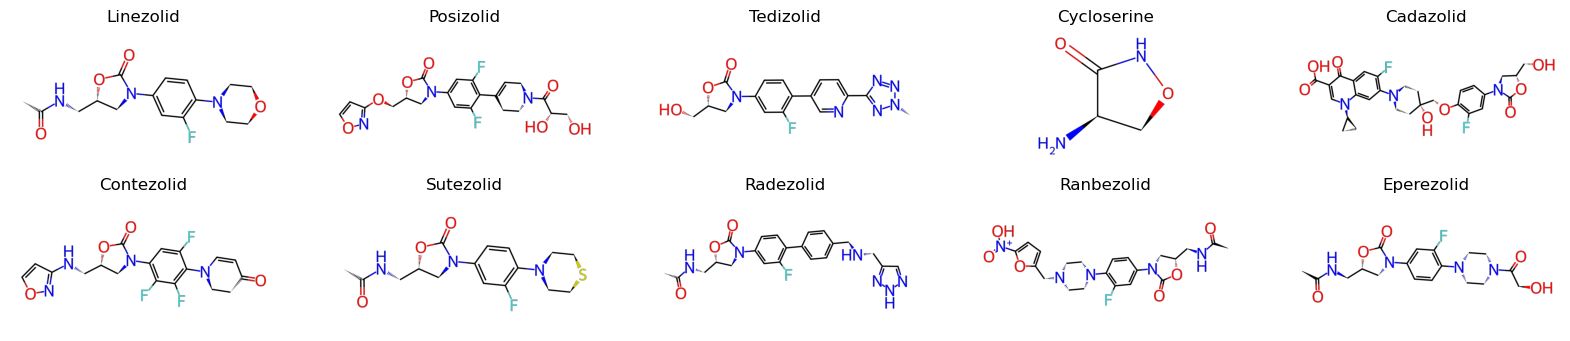

In [3]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 5, figsize=(20, 4))
for i, mol in enumerate(oxazolidinones):
    name = oxazolidinone_names[i]
    ax = axs[i // 5, i % 5]
    ax.imshow(mol.draw2d().draw(fontsize=60, linewidth=5))
    ax.set_title(name)
    ax.axis("off")

Now with those we case use the `make_brics_fragments` function from the `molecular_factories` extension to obtain a list of BRICS fragments from the list of antibiotics.

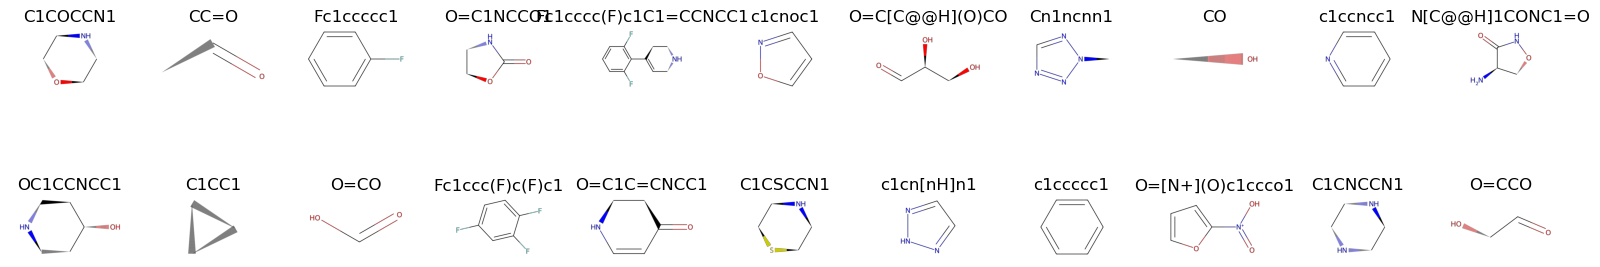

In [4]:
from buildamol.extensions.molecular_factories import make_brics_fragments

# turn the oxazolidinones into BRICS fragments with a minimum of 2 heavy atoms
frags = make_brics_fragments(oxazolidinones, min_heavy_atoms=2)

fig, axs = plt.subplots(2, len(frags) // 2, figsize=(20, 4))
for i, frag in enumerate(frags):
    frag.id = f"brics_{i+1}"
    ax = axs[i // (len(frags) // 2), i % (len(frags) // 2)]
    ax.imshow(frag.draw2d().draw(fontsize=60, linewidth=5))
    ax.set_title(frag.to_smiles())
    ax.axis("off")

And just like that we have a few fragments to work with.

## Using ChEMBL for drug-like molecule fragments

We now have a list of fragmentsn known to be in oxalidinone antibiotics but it is very small and likely not sufficient for a generative pipeline if we were trying to build one. Therefore, let's also us ChEMBL to add more diversity to our library by querying for common drug-like fragments.

We can do so by using the `get_chembl_fragments` function from the `molecular_factories` extension like so:

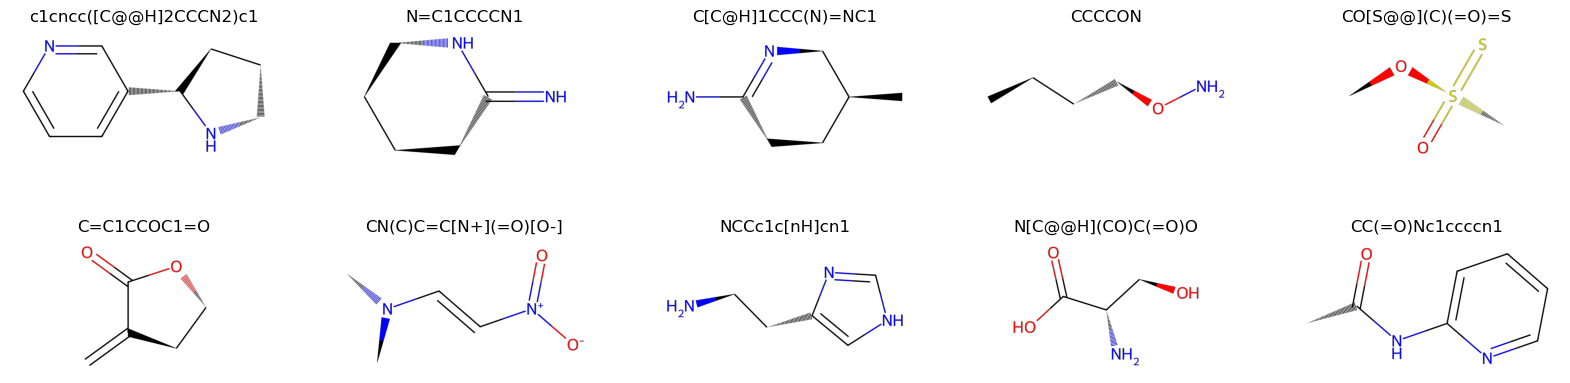

In [6]:
from buildamol.extensions.molecular_factories import get_chembl_fragments

frags_chembl = get_chembl_fragments(n=100, max_mw=150)

fig, axs = plt.subplots(2, 5, figsize=(20, 5))
for i, frag in enumerate(frags_chembl[::10]):
    ax = axs[i // 5, i % 5]
    ax.imshow(frag.draw2d().draw(fontsize=60, linewidth=5))
    ax.set_title(frag.to_smiles())
    ax.axis("off")

We will cover the use of libraries for generative pipelines in another tutorial, so be sure to check that out!  And with that we have reached the end of this tutorial. Thanks a lot for checking it out and good luck with your project using BuildAMol!